In [ ]:
import datetime

import pandas as pd

from expmetrics.datasets.segment.flags_first_user_exposures import FlagsFirstUserExposures
from exp_analysis_tmp.main import ExpAnalysisRunner

In [19]:
# Helper function to filter results based on segment key and metric name

def filter_results(results: pd.DataFrame, segment_key: str | None = None, metric_name: str | None = None) -> pd.DataFrame:
    """Filter results by segment key and metric name."""
    if segment_key:
        results = results[results['segment_key'] == segment_key]
    if metric_name:
        results = results[results['metric_name'] == metric_name]
    return results

First, we need to define experiment key and date range for the experiment we want to analyze (start and end date).

In [32]:
EXPERIMENT_KEY = "sca_payouts_ab_test_v2"
EXPERIMENT_START_DATE = datetime.datetime(2025, 11, 17, 0, 0, 0, 0, tzinfo=datetime.timezone.utc)
COMPUTATION_DATE = datetime.datetime(2026, 1, 1, 0, 0, 0, 0, tzinfo=datetime.timezone.utc)

As at the moment variant names are not standardized in feature-flag experiments, we need to define the control variant name manually.

Here, you can also define which metrics you want to analyze. **IMPORTANT**: If a metric has lag value larger than 0, the compute_to date will be adjusted by subtracting the lag value from it. If the compute_to date is before the lag value, the computation will not be performed.

In [21]:
CONTROL_VARIANT_NAME = "control_group"

METRICS = [
    #payouts
    "attempted_payout_amount_per_payout_attempting_user",
    "users_with_payout_attempt",
    "attempted_payouts",
    "successful_payouts_exposed_time_filter",
    "payout_success_rate",
    "failed_payouts_exposed_time_filter",

    "sellers_per_au",
    "listers_per_au",
    "buyers_per_au",
    "listings_per_lister",
    "gmv_sold_exposed_time_filter",
    "transactions_sold_exposed_time_filter",
    "seller_avg_listing_value",
    "support_ticket_per_active_user"

    

]

As svc-abs experiment-based metric computations used specific segment datasets, built around either A/B test exposures or A/B test assignments, you have to change those with a flag-based exposure or assignment datasets.

While defining the `SEGMENT_DATASETS_MAP`, define which segment dataset should replace the existing dataset. Have in mind that while computing metrics, tables are joined through entity key, so for example, computing transactions for VintedGo lockers is not possible. In addition you should define the `kwargs_to_inherit` dictionary, which will be used to inherit the existing dataset's parameters (for example suspicious users filter, etc.).

In [23]:
SEGMENT_DATASETS_MAP = {
    "AbTestExpose": {
        "alternative_class": FlagsFirstUserExposures,
        "kwargs_to_inherit": {
            "user_filter_type": "_user_filter_type",
        },
    }
}

Then all you need to do is to intialize analysis runner and run the analysis:

In [24]:
exp_analysis_runner = ExpAnalysisRunner(
    segment_dataset_map=SEGMENT_DATASETS_MAP,
    control_variant_name=CONTROL_VARIANT_NAME,
)

Here metric results will automatically be computed per experiment level and per all of the additional segments defined within the segment dataset definition:

In [33]:
results = exp_analysis_runner.run(
    experiment_key=EXPERIMENT_KEY,
    compute_from=EXPERIMENT_START_DATE,
    compute_to=COMPUTATION_DATE,
    metrics=METRICS,
)

/Users/gabijastaponaite/Documents/GitHub/exp-metrics/.venv/lib/python3.12/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


View specific metric results for overall (experiment-level) segment:

In [26]:
filter_results(results, segment_key="OVERALL", metric_name= "support_ticket_per_active_user")

,p_val,rel_diff,rel_diff_lo,rel_diff_up,rel_diff_p_val,rel_diff_se,abs_diff,rmde,abs_diff_lo,abs_diff_up,...,metric_name,variant,compute_from,compute_to,control_cnt,control_avg,control_std_dev,variant_cnt,variant_avg,variant_std_dev
702,0.000228,0.078534,0.03515,0.121917,0.00013,0.022135,0.041028,0.030829,0.019211,0.062845,...,support_ticket_per_active_user,target_group,2025-11-17 00:00:00+00:00,2026-01-28 00:00:00+00:00,87354,0.522426,2.2926,86811,0.563454,2.352188


View specific metric results for country level segment:

In [ ]:
filter_results(results, segment_key="country_code", metric_name="support_ticket_per_active_user")

In [34]:
overall_results = filter_results(results, segment_key="OVERALL")

summary_table = overall_results[[
    'metric_name', 
    'control_avg', 
    'variant_avg', 
    'rel_diff',
    'control_cnt',
    'variant_cnt',
    'abs_diff',
    'p_val',
]].copy()

summary_table['_rel_diff_raw'] = summary_table['rel_diff']
summary_table['_p_val_raw'] = summary_table['p_val']

summary_table = summary_table.rename(columns={
    'metric_name': 'Metric Name',
    'control_avg': 'Control Average',
    'variant_avg': 'Target Average',
    'control_cnt': 'Control Group Size',
    'variant_cnt': 'Target Group Size',
    'abs_diff': 'Absolute Difference',
    'rel_diff': 'Relative Difference (%)',
    'p_val': 'P Value'
})

summary_table['Control Average'] = summary_table['Control Average'].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else "N/A"
)
summary_table['Target Average'] = summary_table['Target Average'].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else "N/A"
)
summary_table['Control Group Size'] = summary_table['Control Group Size'].apply(
    lambda x: f"{int(x):,}" if pd.notna(x) else "N/A"
)
summary_table['Target Group Size'] = summary_table['Target Group Size'].apply(
    lambda x: f"{int(x):,}" if pd.notna(x) else "N/A"
)
summary_table['Absolute Difference'] = summary_table['Absolute Difference'].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else "N/A"
)
summary_table['Relative Difference (%)'] = summary_table['Relative Difference (%)'].apply(
    lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A"
)
summary_table['P Value'] = summary_table['P Value'].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else "N/A"
)

def style_row(row):
    """Style relative difference column"""
    rel_diff = row['_rel_diff_raw']
    p_val = row['_p_val_raw']
    
    styles = [''] * len(row)
    rel_diff_idx = row.index.get_loc('Relative Difference (%)')
    
    if pd.notna(rel_diff) and pd.notna(p_val):
        if abs(rel_diff) > 0 and p_val < 0.05:
            styles[rel_diff_idx] = 'background-color: #ffcccc'
    
    return styles

styled = summary_table.style.apply(style_row, axis=1)
print("="*80)
print("PAYOUTS SCA TEST V2 - whole period")
print("="*80)

styled

PAYOUTS SCA TEST V2 - whole period


,Metric Name,Control Average,Target Average,Relative Difference (%),Control Group Size,Target Group Size,Absolute Difference,P Value,_rel_diff_raw,_p_val_raw
72,attempted_payout_amount_per_payout_attempting_user,1409.880,1775.075,25.90%,"58,285","57,608",365.195,0.000,0.259026,0.000000
73,payout_success_rate,0.979,0.855,-12.62%,"58,285","57,608",-0.123,0.000,-0.126162,0.000000
108,users_with_payout_attempt,1.000,1.000,N/A,"58,285","57,611",-0.000,0.083,nan,0.083265
109,attempted_payouts,3.743,4.417,18.01%,"58,285","57,611",0.674,0.000,0.180144,0.000000
216,successful_payouts_exposed_time_filter,1.630,2.004,22.95%,"58,285","57,611",0.374,0.000,0.229465,0.000000
270,failed_payouts_exposed_time_filter,0.028,0.351,1134.64%,"58,285","57,611",0.322,0.000,11.346397,0.000000
324,sellers_per_au,0.956,0.957,0.10%,"58,285","57,611",0.001,0.435,0.000983,0.434764
378,listers_per_au,0.903,0.903,-0.09%,"58,285","57,611",-0.001,0.645,-0.000886,0.645372
379,seller_avg_listing_value,27.081,26.696,-1.42%,"50,411","49,832",-0.385,0.464,-0.014219,0.463993
486,buyers_per_au,0.508,0.509,0.27%,"58,285","57,611",0.001,0.643,0.002678,0.643191


In [29]:

METRIC_NAME = "payout_success_rate"  # Change this to your desired metric

country_results = filter_results(
    results, 
    segment_key="country_code", 
    metric_name=METRIC_NAME
)

country_table = country_results[[
    'segment_value',  
    'control_avg', 
    'variant_avg', 
    'control_cnt',  
    'variant_cnt', 
    'p_val'
]].copy()

country_table = country_table.rename(columns={
    'segment_value': 'Country',
    'control_avg': 'Control Average',
    'variant_avg': 'Target Average',
    'control_cnt': 'Control Group Size',
    'variant_cnt': 'Target Group Size',
    'p_val': 'P Value'
})

country_table = country_table.sort_values('Country').reset_index(drop=True)

country_table['Control Average'] = country_table['Control Average'].apply(
    lambda x: f"{x:,.4f}" if pd.notna(x) else "N/A"
)
country_table['Target Average'] = country_table['Target Average'].apply(
    lambda x: f"{x:,.4f}" if pd.notna(x) else "N/A"
)
country_table['Control Group Size'] = country_table['Control Group Size'].apply(
    lambda x: f"{int(x):,}" if pd.notna(x) else "N/A"
)
country_table['Target Group Size'] = country_table['Target Group Size'].apply(
    lambda x: f"{int(x):,}" if pd.notna(x) else "N/A"
)
country_table['P Value'] = country_table['P Value'].apply(
    lambda x: f"{x:.4f}" if pd.notna(x) else "N/A"
)

country_table

,Country,Control Average,Target Average,Control Group Size,Target Group Size,P Value
0,AT,0.9982,0.8741,436,395,0.0000
1,BE,0.9915,0.8567,"2,961","2,820",0.0000
2,CZ,0.9976,0.8795,595,551,0.0000
3,DE,0.9843,0.8507,"6,659","6,865",0.0000
4,DK,0.9633,0.9139,"1,245","1,179",0.0028
5,EE,1.0000,0.8793,10,7,0.1927
6,ES,0.9668,0.8429,"4,078","4,030",0.0000
7,FI,1.0000,0.9481,403,426,N/A
8,FR,0.9735,0.8640,"24,997","24,667",0.0000
9,GR,1.0000,0.9209,91,126,0.0057


In [30]:
overall_exposed = filter_results(results, segment_key="OVERALL").iloc[0] if len(filter_results(results, segment_key="OVERALL")) > 0 else None

if overall_exposed is not None:
    exposed_by_variant = pd.DataFrame({
        'variant': ['control_group', overall_exposed['variant']],
        'total_exposed_users': [
            overall_exposed['control_cnt'],
            overall_exposed['variant_cnt']
        ]
    })
    
    print("="*80)
    print(f"TOTAL EXPOSED USERS BY VARIANT - {EXPERIMENT_KEY}")
    print("="*80)
    print(exposed_by_variant.to_string(index=False))
else:
    print("No OVERALL segment data found")

TOTAL EXPOSED USERS BY VARIANT - sca_payouts_ab_test_v2
      variant  total_exposed_users
control_group                87354
 target_group                86807


In [31]:
country_sample_sizes = filter_results(results, segment_key="country_code")

if len(country_sample_sizes) > 0:
    country_totals = country_sample_sizes.groupby('segment_value').agg({
        'control_cnt': 'first',  # All rows for same country should have same counts
        'variant_cnt': 'first'
    }).reset_index()
    
    country_totals['total_sample_size'] = country_totals['control_cnt'] + country_totals['variant_cnt']
    
    country_totals = country_totals.sort_values('total_sample_size', ascending=False)
    
    country_totals_display = country_totals[[
        'segment_value',
        'control_cnt',
        'variant_cnt',
        'total_sample_size'
    ]].rename(columns={
        'segment_value': 'Country',
        'control_cnt': 'Control Group Size',
        'variant_cnt': 'Variant Group Size',
        'total_sample_size': 'Total Sample Size'
    })
    
    print("="*80)
    print(f"SAMPLE SIZES BY COUNTRY (Sorted Descending) - {EXPERIMENT_KEY}")
    print("="*80)
    print(country_totals_display.to_string(index=False))
else:
    print("No country-level segment data found")

SAMPLE SIZES BY COUNTRY (Sorted Descending) - sca_payouts_ab_test_v2
Country  Control Group Size  Variant Group Size  Total Sample Size
     FR               24997               24667              49664
     UK               19146               18987              38133
     IT               12863               12657              25520
     DE                6659                6865              13524
     PL                4971                4898               9869
     NL                4273                4407               8680
     ES                4078                4030               8108
     BE                2961                2820               5781
     DK                1245                1179               2424
     PT                 937                1008               1945
     SE                 943                 920               1863
     HU                 579                 607               1186
     CZ                 595                 551             

In [9]:
import pydata_google_auth
credentials = pydata_google_auth.get_user_credentials(
    [
        'https://www.googleapis.com/auth/cloud-platform', 
        'https://www.googleapis.com/auth/bigquery'
    ],
    use_local_webserver=False
)

import pandas_gbq as pdq

# It should output your vinted email
pdq.read_gbq('select SESSION_USER()').head()
%load_ext google.cloud.bigquery

Downloading: 100%|██████████|
The google.cloud.bigquery extension is already loaded. To reload it, use:
  %reload_ext google.cloud.bigquery


In [12]:
%%bigquery dt --use_rest_api --maximum_bytes_billed=200000000000
WITH test_users AS (
  SELECT DISTINCT
    CAST(targeting_key AS INT64) AS user_id,
    variant
  FROM `vi-dv-prod-grf.contracts.backend_flags_exposure`
  WHERE time >= '2025-12-01'
    AND flag_key = 'sca_payouts_ab_test_v2'
),

sca AS (
  SELECT
    entity_id AS payout_id,
    created_at AS sca_created_at,
    ROW_NUMBER() OVER (
      PARTITION BY entity_id
      ORDER BY updated_at DESC
    ) AS rn
  FROM `vi-dv-prod-mkp.cdc_changelog.svc_payments_compliance_strong_customer_authentications`
  WHERE __kafka_record.timestamp >= '2025-12-01'
    AND entity_type = 20
),

trusted AS (
  SELECT
    bank_account_id,
    MIN(updated_at) AS was_trusted_at
  FROM `dv-mkp-pmnt-prod.staging.stg_cdc__svc_payments_bank_accounts`
  WHERE is_trusted
  GROUP BY bank_account_id
),

payouts AS (
  SELECT 
    a.created_at,
    a.payout_id,
    a.user_id,
    tu.variant,
    b.is_trusted,
    a.bank_account_id,
    a.amount_eur,
    a.status_code,
    a.failure_reason,
    a.payment_provider,

    -- historical trust info
    t.was_trusted_at,

    -- trust status at payout time
    CASE
      WHEN t.was_trusted_at IS NOT NULL
           AND t.was_trusted_at <= a.created_at
        THEN TRUE
      ELSE FALSE
    END AS is_trusted_at_payout

  FROM `dv-mkp-pmnt-prod.marts.mrt_payouts` a
  LEFT JOIN `dv-mkp-pmnt-prod.dimensions.dim_bank_accounts` b
    ON a.bank_account_id = b.bank_account_id
  LEFT JOIN trusted t
    ON a.bank_account_id = t.bank_account_id
  JOIN test_users tu
    ON a.user_id = tu.user_id
  WHERE a.created_at >= '2025-12-01 10:30:00'
  and  a.created_at < '2026-02-01'
),

twofa AS (
  SELECT 
    user_id,
    created_at AS twofa_created_at,
    CASE 
      WHEN status = 0 THEN 'pending' 
      WHEN status = 2 THEN 'confirmed' 
      WHEN status = 4 THEN 'timeout' 
      WHEN status = 5 THEN 'failed' 
      WHEN status = 6 THEN 'created'
    END AS twofa_status,
    ROW_NUMBER() OVER (
      PARTITION BY user_id, id
      ORDER BY updated_at DESC
    ) AS rn
  FROM `vi-dv-prod-mkp.cdc_changelog.core_user_two_factor_auths`
  WHERE __kafka_record.timestamp >= '2025-12-01'
),

payouts_with_interaction AS (
  SELECT
    p.user_id,
    p.variant,
    p.payout_id,
    p.amount_eur,
    p.is_trusted_at_payout,
    p.is_trusted,
    p.was_trusted_at,
    p.created_at,
    p.status_code,
    p.failure_reason,

    -- SCA
    s.sca_created_at,

    -- 2FA
    t.twofa_created_at,
    t.twofa_status,

    ROW_NUMBER() OVER (
      PARTITION BY p.user_id
      ORDER BY p.created_at
    ) AS payout_order
  FROM payouts p
  LEFT JOIN sca s
    ON p.payout_id = s.payout_id
    AND s.rn = 1
  LEFT JOIN twofa t
    ON p.user_id = t.user_id
    AND t.rn = 1
    AND t.twofa_created_at BETWEEN p.created_at
      AND TIMESTAMP_ADD(p.created_at, INTERVAL 1 MINUTE)
)

SELECT 
  user_id,
  variant,
  payout_id,
  amount_eur,
  amount_eur >= 500 AS is_high_amount_payout,
  is_trusted_at_payout,
  is_trusted,
  was_trusted_at,
  created_at,
  sca_created_at,
  status_code AS payment_status,
  failure_reason,
  twofa_created_at,
  twofa_status
FROM payouts_with_interaction;


Query is running:   0%|          |

Downloading:   0%|          |

In [13]:
df= dt

In [14]:

target_group_df = df[df['amount_eur']  >= 500].copy()
target_group_df = df[df['variant'] == 'control_group'].copy()
failed_payments_df = target_group_df[target_group_df['failure_reason'].notna()].copy()

failure_reason_shares = failed_payments_df.groupby('failure_reason').agg({
    'payout_id': 'count',  # Count of failed payouts per failure reason
    'user_id': 'nunique'   # Distinct users that experienced each failure reason
}).reset_index()

failure_reason_shares.columns = ['Failure Reason', 'Count', 'Distinct Users']
total_failed_payments = len(failed_payments_df)
failure_reason_shares['Percentage (%)'] = (failure_reason_shares['Count'] / total_failed_payments * 100).round(2)

failure_reason_shares = failure_reason_shares.sort_values('Count', ascending=False).reset_index(drop=True)

failure_reason_shares_display = failure_reason_shares.copy()
failure_reason_shares_display['Count'] = failure_reason_shares_display['Count'].apply(lambda x: f"{int(x):,}")
failure_reason_shares_display['Distinct Users'] = failure_reason_shares_display['Distinct Users'].apply(lambda x: f"{int(x):,}")
failure_reason_shares_display['Percentage (%)'] = failure_reason_shares_display['Percentage (%)'].apply(lambda x: f"{x:.2f}%")

print("="*80)
print("FAILURE REASON SHARES - TARGET GROUP (FROM FAILED PAYMENTS)")
print("="*80)
print(f"Total failed payments in target group: {total_failed_payments:,}")
print(f"Total payouts in target group: {len(target_group_df):,}")
print("="*80)

# Keep the numeric version for further analysis if needed
failure_reason_shares.head(10)

FAILURE REASON SHARES - TARGET GROUP (FROM FAILED PAYMENTS)
Total failed payments in target group: 10,233
Total payouts in target group: 442,339


,Failure Reason,Count,Distinct Users,Percentage (%)
0,User blocked by Fraud policy,3656,358,35.73
1,Expired,1419,557,13.87
2,RR04,1000,244,9.77
3,Blocked due to the Bank Account User's KYC lim...,953,773,9.31
4,Transaction blocked by Fraud Policy,739,130,7.22
5,MS03,562,230,5.49
6,Transaction refused due to blocked IBAN,175,50,1.71
7,Transaction blocked by Fraud policy,162,55,1.58
8,Insufficient wallet balance,161,33,1.57
9,AG01,156,51,1.52


In [15]:

target_group_df = df[df['variant'] == 'target_group'].copy()
target_group_df = df[df['amount_eur']  >= 500].copy()
failed_payments_df = target_group_df[target_group_df['failure_reason'].notna()].copy()

failure_reason_shares = failed_payments_df.groupby('failure_reason').agg({
    'payout_id': 'count',  # Count of failed payouts per failure reason
    'user_id': 'nunique'   # Distinct users that experienced each failure reason
}).reset_index()

failure_reason_shares.columns = ['Failure Reason', 'Count', 'Distinct Users']
total_failed_payments = len(failed_payments_df)
failure_reason_shares['Percentage (%)'] = (failure_reason_shares['Count'] / total_failed_payments * 100).round(2)

failure_reason_shares = failure_reason_shares.sort_values('Count', ascending=False).reset_index(drop=True)

failure_reason_shares_display = failure_reason_shares.copy()
failure_reason_shares_display['Count'] = failure_reason_shares_display['Count'].apply(lambda x: f"{int(x):,}")
failure_reason_shares_display['Distinct Users'] = failure_reason_shares_display['Distinct Users'].apply(lambda x: f"{int(x):,}")
failure_reason_shares_display['Percentage (%)'] = failure_reason_shares_display['Percentage (%)'].apply(lambda x: f"{x:.2f}%")

print("="*80)
print("FAILURE REASON SHARES - TARGET GROUP (FROM FAILED PAYMENTS)")
print("="*80)
print(f"Total failed payments in target group: {total_failed_payments:,}")
print(f"Total payouts in target group: {len(target_group_df):,}")
print("="*80)

# Keep the numeric version for further analysis if needed
failure_reason_shares.head(10)

FAILURE REASON SHARES - TARGET GROUP (FROM FAILED PAYMENTS)
Total failed payments in target group: 49,130
Total payouts in target group: 313,997


,Failure Reason,Count,Distinct Users,Percentage (%)
0,Expired,41586,20937,84.64
1,User blocked by Fraud policy,3804,593,7.74
2,RR04,556,312,1.13
3,Transaction blocked by Fraud Policy,494,147,1.01
4,MS03,433,248,0.88
5,Insufficient wallet balance,339,76,0.69
6,Blocked due to the Bank Account User's KYC lim...,326,324,0.66
7,Transaction refused due to blocked IBAN,225,81,0.46
8,Transaction blocked by Fraud policy,128,59,0.26
9,AG01,112,67,0.23


/var/folders/g_/h_cc5fns4zv379crp412314w0000gn/T/ipykernel_74717/1208931808.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['created_at'].dt.to_period('W').dt.start_time


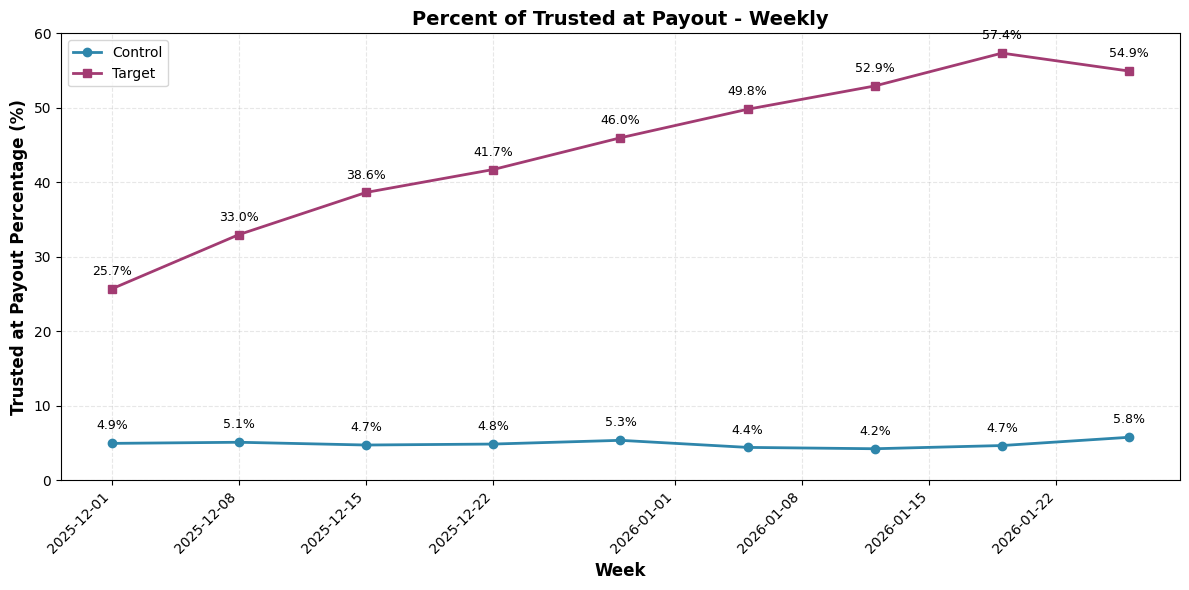

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df['created_at'] = pd.to_datetime(df['created_at'])
df['week'] = df['created_at'].dt.to_period('W').dt.start_time

weekly_stats = df.groupby(['week', 'variant']).agg({
    'payout_id': 'count',
    'is_trusted_at_payout': 'sum'
}).reset_index()
weekly_stats['pct'] = (weekly_stats['is_trusted_at_payout'] / weekly_stats['payout_id'] * 100).round(2)

control = weekly_stats[weekly_stats['variant'] == 'control_group'].sort_values('week')
target = weekly_stats[weekly_stats['variant'] == 'target_group'].sort_values('week')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(control['week'], control['pct'], marker='o', linewidth=2, markersize=6, label='Control', color='#2E86AB')
ax.plot(target['week'], target['pct'], marker='s', linewidth=2, markersize=6, label='Target', color='#A23B72')

for _, row in control.iterrows():
    ax.annotate(f"{row['pct']:.1f}%", (row['week'], row['pct']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
for _, row in target.iterrows():
    ax.annotate(f"{row['pct']:.1f}%", (row['week'], row['pct']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

ax.set_xlabel('Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Trusted at Payout Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Percent of Trusted at Payout - Weekly', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(bottom=0)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/var/folders/g_/h_cc5fns4zv379crp412314w0000gn/T/ipykernel_74717/3661214565.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['created_at'].dt.to_period('W').dt.start_time


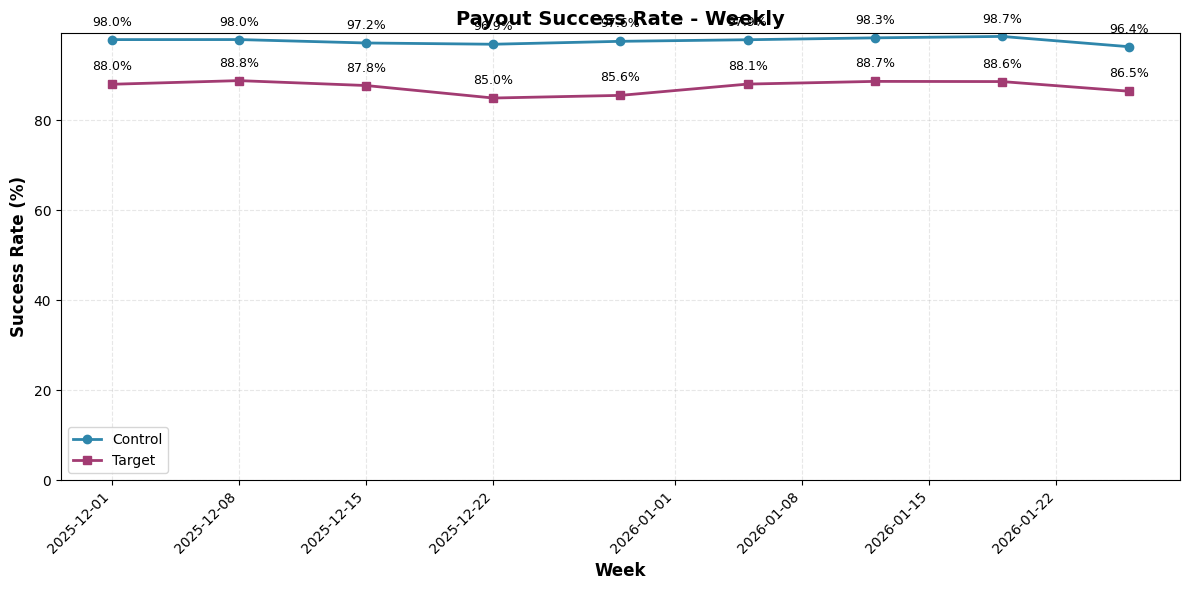

In [17]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['week'] = df['created_at'].dt.to_period('W').dt.start_time
df['is_successful'] = df['failure_reason'].isna()

weekly_stats = df.groupby(['week', 'variant']).agg({
    'payout_id': 'count',
    'is_successful': 'sum'
}).reset_index()
weekly_stats['success_rate'] = (weekly_stats['is_successful'] / weekly_stats['payout_id'] * 100).round(2)

control = weekly_stats[weekly_stats['variant'] == 'control_group'].sort_values('week')
target = weekly_stats[weekly_stats['variant'] == 'target_group'].sort_values('week')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(control['week'], control['success_rate'], marker='o', linewidth=2, markersize=6, label='Control', color='#2E86AB')
ax.plot(target['week'], target['success_rate'], marker='s', linewidth=2, markersize=6, label='Target', color='#A23B72')

for _, row in control.iterrows():
    ax.annotate(f"{row['success_rate']:.1f}%", (row['week'], row['success_rate']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
for _, row in target.iterrows():
    ax.annotate(f"{row['success_rate']:.1f}%", (row['week'], row['success_rate']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

ax.set_xlabel('Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Payout Success Rate - Weekly', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(bottom=0)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()